In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================
# 1. Imports and Device Configuration
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU: CUDA")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using GPU: Apple MPS")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: CUDA


In [ ]:
# ==========================================
# 2. Data Loading & Feature Engineering
# ==========================================
file_path = "/content/drive/MyDrive/STAT946/cleaned_data_toronto_downtown.csv"
df = pd.read_csv(file_path)

df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

# Select meteorological and air quality features
base_features = [
    'PM_ppb', 'Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)',
    'Precip. Amount (mm)', 'Wind Spd (km/h)', 'Stn Press (kPa)'
]
df_imputed = df[base_features].copy() # Assuming no missing values as requested

# Apply physical constraints (no negative PM2.5, humidity, etc.)
non_negative_cols = ['PM_ppb', 'Rel Hum (%)', 'Precip. Amount (mm)', 'Wind Spd (km/h)']
for col in non_negative_cols:
    df_imputed[col] = df_imputed[col].clip(lower=0)

df_imputed['Datetime'] = df['Datetime']

# Cyclical Time Features (Crucial for deep learning temporal awareness)
df_imputed['hour'] = df_imputed['Datetime'].dt.hour
df_imputed['month'] = df_imputed['Datetime'].dt.month

df_imputed['hour_sin'] = np.sin(2 * np.pi * df_imputed['hour'] / 24.0)
df_imputed['hour_cos'] = np.cos(2 * np.pi * df_imputed['hour'] / 24.0)
df_imputed['month_sin'] = np.sin(2 * np.pi * df_imputed['month'] / 12.0)
df_imputed['month_cos'] = np.cos(2 * np.pi * df_imputed['month'] / 12.0)

final_features = base_features + ['hour_sin', 'hour_cos', 'month_sin', 'month_cos']
df_model = df_imputed[final_features].copy()

print(f"Dataset shape ready for Dynamic Generation: {df_model.shape}")

Dataset shape ready for Dynamic Generation: (56493, 11)


In [ ]:
# ==========================================
# 3. Dynamic Data Preparation Function
# ==========================================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_model)

TARGET_INDEX = 0
HORIZONS = [4, 6, 24]
INPUT_DIM = len(final_features)
OUTPUT_DIM = len(HORIZONS)

def prepare_data(seq_len):
    """Generates dynamic sequences based on the given look-back window (seq_len)"""
    max_horizon = max(HORIZONS)
    n_samples = len(scaled_data) - seq_len - max_horizon + 1

    xs = np.zeros((n_samples, seq_len, scaled_data.shape[1]), dtype=np.float32)
    ys = np.zeros((n_samples, len(HORIZONS)), dtype=np.float32)

    for i in range(n_samples):
        xs[i] = scaled_data[i : i + seq_len]
        ys[i] = [scaled_data[i + seq_len + h - 1, TARGET_INDEX] for h in HORIZONS]

    # Standard 70% / 15% / 15% Split
    train_end = int(len(xs) * 0.70)
    val_end = int(len(xs) * 0.85)

    splits = {
        'X_train': xs[:train_end], 'y_train': ys[:train_end],
        'X_val': xs[train_end:val_end], 'y_val': ys[train_end:val_end],
        'X_test': xs[val_end:], 'y_test': ys[val_end:]
    }
    return splits

def get_dataloaders(splits, batch_size=256):
    """Converts numpy splits into PyTorch Dataloaders"""
    X_train_t = torch.tensor(splits['X_train']).to(device)
    y_train_t = torch.tensor(splits['y_train']).to(device)
    X_val_t = torch.tensor(splits['X_val']).to(device)
    y_val_t = torch.tensor(splits['y_val']).to(device)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, X_val_t, y_val_t

In [ ]:
# ==========================================
# 4. Official N-HiTS Architecture (Paper & GitHub Aligned)
# ==========================================
import torch.nn.functional as F

class NHITSBlock(nn.Module):
    """
    A single N-HiTS block following the official doubly residual implementation.
    Includes MaxPool1d for input downsampling and F.interpolate for output upsampling.
    """
    def __init__(self, input_dim, seq_len, max_horizon, pool_size, n_theta, hidden_dim, dropout_rate):
        super().__init__()
        self.pool_size = pool_size
        self.seq_len = seq_len
        self.input_dim = input_dim
        self.max_horizon = max_horizon

        # Calculate length after MaxPool1d (ceil_mode=True as per GitHub)
        self.pooled_seq_len = int(np.ceil(seq_len / pool_size))
        flat_dim = input_dim * self.pooled_seq_len

        # Standard 2-Layer MLP for feature extraction
        self.mlp = nn.Sequential(
            nn.Linear(flat_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1)
        )

        # Basis Expansion Linear Layers
        self.theta_b = nn.Linear(hidden_dim, seq_len * input_dim) # Backcast (reconstruction)
        self.theta_f = nn.Linear(hidden_dim, n_theta)             # Forecast (basis knots)

    def forward(self, x):
        # 1. Multi-Rate Pooling (Downsampling)
        x_pool = x.permute(0, 2, 1) # Shape: (Batch, Features, Time)
        if self.pool_size > 1:
            x_pool = F.max_pool1d(x_pool, kernel_size=self.pool_size, stride=self.pool_size, ceil_mode=True)

        # 2. Extract Features
        x_flat = x_pool.reshape(x_pool.size(0), -1)
        h = self.mlp(x_flat)

        # 3. Backcast (Project back to original input shape)
        backcast = self.theta_b(h).reshape(-1, self.seq_len, self.input_dim)

        # 4. Hierarchical Interpolation Forecast (Upsampling)
        theta_f = self.theta_f(h).unsqueeze(1) # Shape: (Batch, 1, n_theta)
        forecast = F.interpolate(theta_f, size=self.max_horizon, mode='linear', align_corners=True).squeeze(1)

        return backcast, forecast

class ModelNHITS(nn.Module):
    def __init__(self, input_dim, seq_len, output_dim=3, hidden_dim=128, dropout_rate=0.1):
        super().__init__()
        self.max_horizon = 24 # Interpolate out to a continuous 24-hour horizon

        # Stack 1: Low Frequency (Macro trends, high pooling, few interpolation knots)
        self.block1 = NHITSBlock(input_dim, seq_len, self.max_horizon, pool_size=4, n_theta=self.max_horizon//4, hidden_dim=hidden_dim, dropout_rate=dropout_rate)

        # Stack 2: Mid Frequency
        self.block2 = NHITSBlock(input_dim, seq_len, self.max_horizon, pool_size=2, n_theta=self.max_horizon//2, hidden_dim=hidden_dim, dropout_rate=dropout_rate)

        # Stack 3: High Frequency (Micro shocks, no pooling, high interpolation knots)
        self.block3 = NHITSBlock(input_dim, seq_len, self.max_horizon, pool_size=1, n_theta=self.max_horizon, hidden_dim=hidden_dim, dropout_rate=dropout_rate)

        # Since the model interpolates 24 steps (1h to 24h), we extract only the specific indices
        # Index 3 = +4h, Index 5 = +6h, Index 23 = +24h
        self.target_indices = [3, 5, 23]

    def forward(self, x):
        residuals = x

        # Doubly Residual Network Flow (x = x - backcast)
        b1, f1 = self.block1(residuals)
        residuals = residuals - b1

        b2, f2 = self.block2(residuals)
        residuals = residuals - b2

        _, f3 = self.block3(residuals)

        # Accumulate the interpolated forecasts
        forecast_24h = f1 + f2 + f3

        # Slice out the specific 4h, 6h, and 24h predictions
        return forecast_24h[:, self.target_indices]

In [ ]:
# ==========================================
# 5. N-HiTS Grid Search
# ==========================================
import warnings
warnings.filterwarnings('ignore')

# 32 carefully selected combinations
param_grid_nhits = {
    'seq_len': [12, 16, 24, 48],
    'lr': [0.0005, 0.001, 0.005],
    'hidden_dim': [64, 128, 256, 512],
    'dropout_rate': [0.1, 0.2, 0.3]
}
grid_nhits = ParameterGrid(param_grid_nhits)

best_nhits_val_mse = float('inf')
best_nhits_params = None
best_nhits_weights = None

print(f"--- Starting N-HiTS Grid Search ({len(grid_nhits)} combinations) ---")
for i, params in enumerate(grid_nhits):
    splits = prepare_data(params['seq_len'])
    train_loader, val_loader, X_val_t, y_val_t = get_dataloaders(splits)

    model = ModelNHITS(INPUT_DIM, params['seq_len'], OUTPUT_DIM, params['hidden_dim'], params['dropout_rate']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    criterion = nn.MSELoss()

    run_best_val = float('inf')
    epochs_no_improve = 0
    patience = 4 # Aggressive early stopping to speed up the grid search

    for epoch in range(25):
        model.train()
        for bx, by in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for bx_val, by_val in val_loader:
                val_loss += criterion(model(bx_val), by_val).item()
        avg_val = val_loss / len(val_loader)

        if avg_val < run_best_val:
            run_best_val = avg_val
            epochs_no_improve = 0
            run_best_weights = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    if run_best_val < best_nhits_val_mse:
        best_nhits_val_mse = run_best_val
        best_nhits_params = params
        best_nhits_weights = copy.deepcopy(run_best_weights)
        print(f"  [Run {i+1}] 🌟 New Best -> Params: {params} | Val MSE: {best_nhits_val_mse:.4f}")

print("\n" + "="*50)
print(f"✅ FINAL Best N-HiTS Params: {best_nhits_params}")

--- Starting N-HiTS Grid Search (144 combinations) ---
  [Run 1] 🌟 New Best -> Params: {'dropout_rate': 0.1, 'hidden_dim': 64, 'lr': 0.0005, 'seq_len': 12} | Val MSE: 0.3189
  [Run 3] 🌟 New Best -> Params: {'dropout_rate': 0.1, 'hidden_dim': 64, 'lr': 0.0005, 'seq_len': 24} | Val MSE: 0.3182
  [Run 7] 🌟 New Best -> Params: {'dropout_rate': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'seq_len': 24} | Val MSE: 0.3171
  [Run 9] 🌟 New Best -> Params: {'dropout_rate': 0.1, 'hidden_dim': 64, 'lr': 0.005, 'seq_len': 12} | Val MSE: 0.3155
  [Run 49] 🌟 New Best -> Params: {'dropout_rate': 0.2, 'hidden_dim': 64, 'lr': 0.0005, 'seq_len': 12} | Val MSE: 0.3155
  [Run 55] 🌟 New Best -> Params: {'dropout_rate': 0.2, 'hidden_dim': 64, 'lr': 0.001, 'seq_len': 24} | Val MSE: 0.3123
  [Run 59] 🌟 New Best -> Params: {'dropout_rate': 0.2, 'hidden_dim': 64, 'lr': 0.005, 'seq_len': 24} | Val MSE: 0.3111
  [Run 98] 🌟 New Best -> Params: {'dropout_rate': 0.3, 'hidden_dim': 64, 'lr': 0.0005, 'seq_len': 16} | Val MSE: 

In [ ]:
# ==========================================
# 6. Extract Predictions & Calculate Confidence Intervals
# ==========================================
def inverse_transform_target(scaled_targets):
    dummy = np.zeros((len(scaled_targets), len(final_features)))
    dummy[:, TARGET_INDEX] = scaled_targets
    return scaler.inverse_transform(dummy)[:, TARGET_INDEX]

# 1. Rebuild and load the absolute best model
splits_nhits = prepare_data(best_nhits_params['seq_len'])
best_nhits_model = ModelNHITS(
    INPUT_DIM,
    best_nhits_params['seq_len'],
    OUTPUT_DIM,
    best_nhits_params['hidden_dim'],
    best_nhits_params['dropout_rate']
).to(device)

best_nhits_model.load_state_dict(best_nhits_weights)
best_nhits_model.eval()

# 2. Calculate Standard Deviation (SD) on Validation Set for Confidence Bands
X_val_t = torch.tensor(splits_nhits['X_val']).to(device)
with torch.no_grad():
    val_preds_scaled = best_nhits_model(X_val_t).cpu().numpy()

val_preds_raw = np.array([inverse_transform_target(val_preds_scaled[:, h]) for h in range(len(HORIZONS))]).T
y_val_raw = np.array([inverse_transform_target(splits_nhits['y_val'][:, h]) for h in range(len(HORIZONS))]).T

validation_errors = val_preds_raw - y_val_raw
horizon_std_devs = np.std(validation_errors, axis=0)
print("Calculated Empirical Standard Deviations (4h, 6h, 24h):", horizon_std_devs)

# 3. Generate Final Test Predictions
X_test_t = torch.tensor(splits_nhits['X_test']).to(device)
with torch.no_grad():
    nhits_preds_scaled = best_nhits_model(X_test_t).cpu().numpy()

final_y_test_raw = np.array([inverse_transform_target(splits_nhits['y_test'][:, h]) for h in range(len(HORIZONS))]).T
final_preds_raw = np.array([inverse_transform_target(nhits_preds_scaled[:, h]) for h in range(len(HORIZONS))]).T

print("Test Set Predictions generated successfully.")

Calculated Empirical Standard Deviations (4h, 6h, 24h): [3.32341406 3.64418818 4.41331409]
Test Set Predictions generated successfully.



=== RMSE Comparison on Final Test Set (ppb) ===
Horizon      | N-HiTS (Paper Architecture)
---------------------------------------------
+4 Hours     | 6.97
+6 Hours     | 7.59
+24 Hours     | 8.75




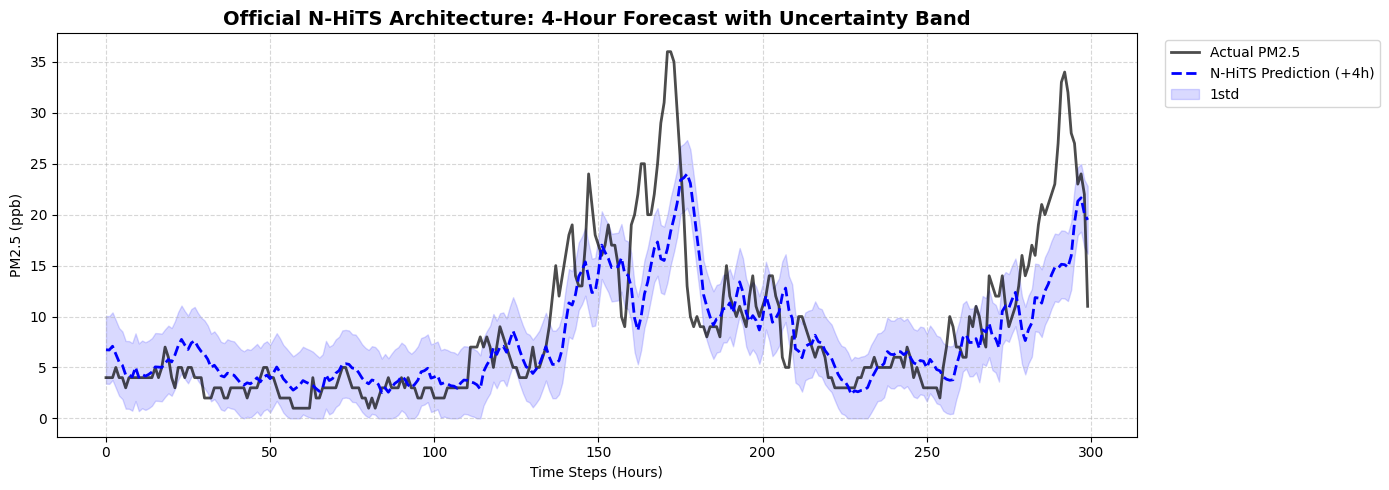

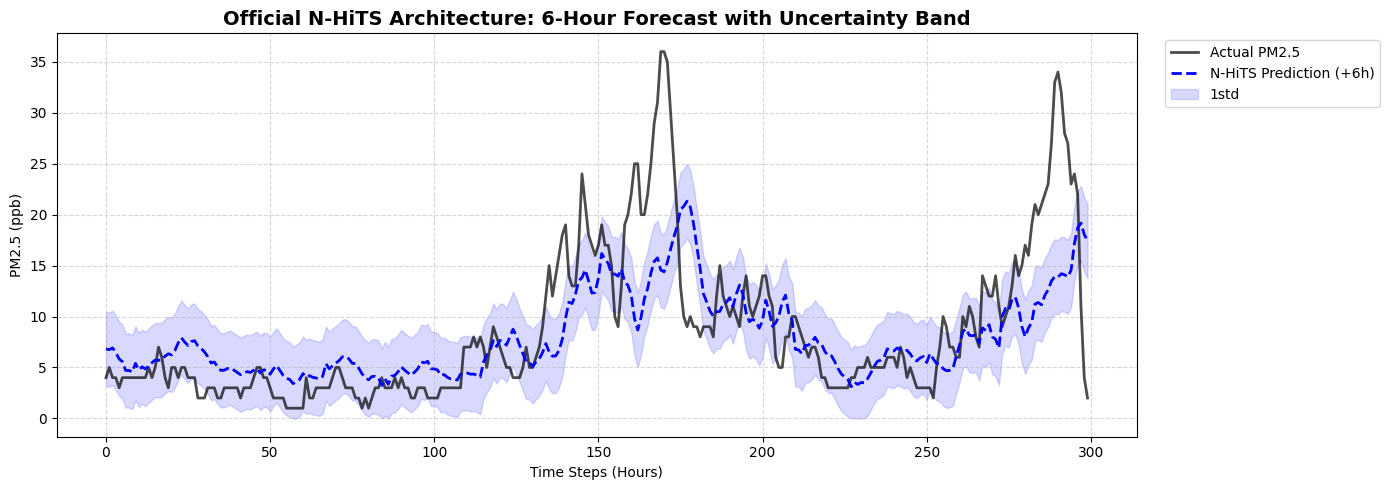

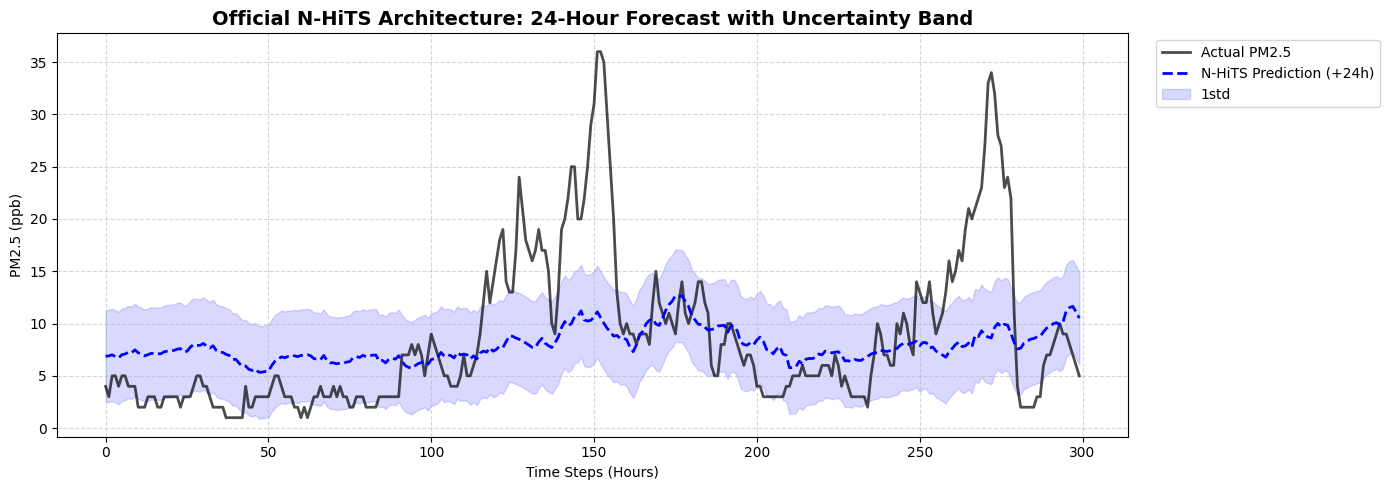

In [ ]:
# ==========================================
# 7. Visualization with 95% Confidence Intervals
# ==========================================
PLOT_LEN = 300
model_color = 'blue'

print("\n=== RMSE Comparison on Final Test Set (ppb) ===")
print(f"{'Horizon':<12} | N-HiTS (Paper Architecture)")
print("-" * 45)
for i, h in enumerate(HORIZONS):
    rmse = np.sqrt(mean_squared_error(final_y_test_raw[:, i], final_preds_raw[:, i]))
    print(f"+{h} Hours     | {rmse:.2f}")
print("\n")

# Separate Line Plots with Confidence Bands
for h_idx, h in enumerate(HORIZONS):
    plt.figure(figsize=(14, 5))

    actual = final_y_test_raw[:PLOT_LEN, h_idx]
    predicted = final_preds_raw[:PLOT_LEN, h_idx]

    # 95% Confidence Interval (1.96 * SD)
    margin_of_error = 1 * horizon_std_devs[h_idx]
    lower_bound = np.maximum(0, predicted - margin_of_error)
    upper_bound = predicted + margin_of_error

    x_axis = np.arange(PLOT_LEN)
    plt.plot(x_axis, actual, label='Actual PM2.5', color='black', alpha=0.7, linewidth=2)
    plt.plot(x_axis, predicted, label=f'N-HiTS Prediction (+{h}h)', color=model_color, linestyle='--', linewidth=2)

    # Fill the Shaded Confidence Band
    plt.fill_between(x_axis, lower_bound, upper_bound, color=model_color, alpha=0.15, label='1std')

    plt.title(f'Official N-HiTS Architecture: {h}-Hour Forecast with Uncertainty Band', fontsize=14, fontweight='bold')
    plt.ylabel('PM2.5 (ppb)')
    plt.xlabel('Time Steps (Hours)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()